In [1]:
import numpy as np

x = np.array([6, 20])

w = np.array([5, 0.2])

b = 10

z = np.dot(w, x) + b

print("Weighted sum:", z)

Weighted sum: 44.0


In [2]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

output = sigmoid(z)

print("Neuron output:", output)

Neuron output: 1.0


In [3]:
def relu(z):
    return np.maximum(0, z)

for value in [-3, -1, 0, 2, 5]:
    print(value, "→", relu(value))

-3 → 0
-1 → 0
0 → 0
2 → 2
5 → 5


In [4]:
x = 2
y = 10

w = 3
b = 0

learning_rate = 0.1

for i in range(5):

    # Forward pass
    z = w * x + b
    prediction = max(0, z)  # ReLU

    # Loss
    loss = (y - prediction) ** 2

    # Backpropagation
    dL_dprediction = 2 * (prediction - y)

    # ReLU gradient
    dz_dprediction = 1 if z > 0 else 0

    # Gradient of weight
    dL_dw = dL_dprediction * dz_dprediction * x

    # Gradient descent
    w = w - learning_rate * dL_dw

    print(
        f"Step {i+1}: "
        f"prediction={prediction:.2f}, "
        f"loss={loss:.2f}, "
        f"weight={w:.2f}"
    )

Step 1: prediction=6.00, loss=16.00, weight=4.60
Step 2: prediction=9.20, loss=0.64, weight=4.92
Step 3: prediction=9.84, loss=0.03, weight=4.98
Step 4: prediction=9.97, loss=0.00, weight=5.00
Step 5: prediction=9.99, loss=0.00, weight=5.00


In [5]:
dL_db = dL_dprediction * dz_dprediction * 1

In [6]:
b = b - learning_rate * dL_db

In [7]:
x = 2
y = 10

w = 3
b = 0

learning_rate = 0.1

for i in range(5):

    # Forward pass
    z = w * x + b
    prediction = max(0, z)

    # Loss
    loss = (y - prediction) ** 2

    # Backpropagation
    dL_dprediction = 2 * (prediction - y)

    # ReLU gradient
    dz_dprediction = 1 if z > 0 else 0

    # Gradients
    dL_dw = dL_dprediction * dz_dprediction * x
    dL_db = dL_dprediction * dz_dprediction * 1

    # Update
    w = w - learning_rate * dL_dw
    b = b - learning_rate * dL_db

    print(
        f"Step {i+1}: "
        f"prediction={prediction:.2f}, "
        f"loss={loss:.2f}, "
        f"weight={w:.2f}, "
        f"bias={b:.2f}"
    )

Step 1: prediction=6.00, loss=16.00, weight=4.60, bias=0.80
Step 2: prediction=10.00, loss=0.00, weight=4.60, bias=0.80
Step 3: prediction=10.00, loss=0.00, weight=4.60, bias=0.80
Step 4: prediction=10.00, loss=0.00, weight=4.60, bias=0.80
Step 5: prediction=10.00, loss=0.00, weight=4.60, bias=0.80


In [8]:
%pip install torch torchvision torchaudio



[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [9]:
import torch

print(torch.__version__)

2.14.0


In [10]:
x = [2]

In [11]:
import torch

x = torch.tensor([2.0])
y = torch.tensor([10.0])

print(x)
print(y)

tensor([2.])
tensor([10.])


In [12]:
import torch
import torch.nn as nn

neuron = nn.Linear(1, 1)

print(neuron)

Linear(in_features=1, out_features=1, bias=True)


In [13]:
x = torch.tensor([[2.0]])

output = neuron(x)

print(output)

tensor([[2.2246]], grad_fn=<AddmmBackward0>)


In [14]:
print("Weight:", neuron.weight)
print("Bias:", neuron.bias)

Weight: Parameter containing:
tensor([[0.8867]], requires_grad=True)
Bias: Parameter containing:
tensor([0.4512], requires_grad=True)


In [15]:
y = 10

In [16]:
y = torch.tensor([[10.0]])

loss_fn = nn.MSELoss()

loss = loss_fn(output, y)

print("Prediction:", output.item())
print("Loss:", loss.item())

Prediction: 2.224611282348633
Loss: 60.456668853759766


In [17]:
loss.backward()


In [18]:
print("Weight gradient:", neuron.weight.grad)
print("Bias gradient:", neuron.bias.grad)

Weight gradient: tensor([[-31.1016]])
Bias gradient: tensor([-15.5508])


In [19]:
optimizer = torch.optim.SGD(neuron.parameters(), lr=0.1)

optimizer.step()

print("Weight:", neuron.weight.item())
print("Bias:", neuron.bias.item())

Weight: 3.996861219406128
Bias: 2.006277561187744


In [20]:
for epoch in range(10):
    optimizer.zero_grad()

    output = neuron(x)
    loss = loss_fn(output, y)

    loss.backward()
    optimizer.step()

    print(epoch, loss.item())

0 0.0
1 0.0
2 0.0
3 0.0
4 0.0
5 0.0
6 0.0
7 0.0
8 0.0
9 0.0


In [21]:
neuron = nn.Linear(1, 1)

optimizer = torch.optim.SGD(neuron.parameters(), lr=0.1)

for epoch in range(10):
    optimizer.zero_grad()

    output = neuron(x)
    loss = loss_fn(output, y)

    loss.backward()
    optimizer.step()

    print(
        f"Epoch {epoch+1}: "
        f"Prediction={output.item():.2f}, "
        f"Loss={loss.item():.2f}"
    )

Epoch 1: Prediction=-0.21, Loss=104.34
Epoch 2: Prediction=10.00, Loss=0.00
Epoch 3: Prediction=10.00, Loss=0.00
Epoch 4: Prediction=10.00, Loss=0.00
Epoch 5: Prediction=10.00, Loss=0.00
Epoch 6: Prediction=10.00, Loss=0.00
Epoch 7: Prediction=10.00, Loss=0.00
Epoch 8: Prediction=10.00, Loss=0.00
Epoch 9: Prediction=10.00, Loss=0.00
Epoch 10: Prediction=10.00, Loss=0.00


In [22]:
x_train = torch.tensor([
    [2.0],
    [4.0],
    [6.0],
    [8.0]
])

y_train = torch.tensor([
    [20.0],
    [40.0],
    [60.0],
    [80.0]
])

print(x_train)
print(y_train)

tensor([[2.],
        [4.],
        [6.],
        [8.]])
tensor([[20.],
        [40.],
        [60.],
        [80.]])


In [23]:
neuron = nn.Linear(1, 1)

predictions = neuron(x_train)

print(predictions)
print(predictions.shape)

tensor([[-1.7779],
        [-3.5779],
        [-5.3779],
        [-7.1778]], grad_fn=<AddmmBackward0>)
torch.Size([4, 1])


In [24]:
loss_fn = nn.MSELoss()

loss = loss_fn(predictions, y_train)

print("Predictions:")
print(predictions)

print("\nActual:")
print(y_train)

print("\nLoss:", loss.item())

Predictions:
tensor([[-1.7779],
        [-3.5779],
        [-5.3779],
        [-7.1778]], grad_fn=<AddmmBackward0>)

Actual:
tensor([[20.],
        [40.],
        [60.],
        [80.]])

Loss: 3561.888671875


In [25]:
optimizer = torch.optim.SGD(neuron.parameters(), lr=0.01)

for epoch in range(100):
    optimizer.zero_grad()

    predictions = neuron(x_train)
    loss = loss_fn(predictions, y_train)

    loss.backward()
    optimizer.step()

    if epoch % 10 == 0:
        print(f"Epoch {epoch}: Loss = {loss.item():.2f}")

Epoch 0: Loss = 3561.89
Epoch 10: Loss = 0.51
Epoch 20: Loss = 0.47
Epoch 30: Loss = 0.44
Epoch 40: Loss = 0.42
Epoch 50: Loss = 0.39
Epoch 60: Loss = 0.36
Epoch 70: Loss = 0.34
Epoch 80: Loss = 0.32
Epoch 90: Loss = 0.30


In [26]:
print("Weight:", neuron.weight.item())
print("Bias:", neuron.bias.item())

print("\nPredictions:")
print(neuron(x_train))


Weight: 9.782254219055176
Bias: 1.2994168996810913

Predictions:
tensor([[20.8639],
        [40.4284],
        [59.9929],
        [79.5574]], grad_fn=<AddmmBackward0>)


In [27]:
import torch.nn as nn

model = nn.Sequential(
    nn.Linear(1, 3),
    nn.ReLU(),
    nn.Linear(3, 1)
)

print(model)

Sequential(
  (0): Linear(in_features=1, out_features=3, bias=True)
  (1): ReLU()
  (2): Linear(in_features=3, out_features=1, bias=True)
)


In [28]:
predictions = model(x_train)

print(predictions)
print(predictions.shape)

tensor([[-0.2922],
        [-0.6895],
        [-1.0315],
        [-1.3646]], grad_fn=<AddmmBackward0>)
torch.Size([4, 1])


In [29]:
loss_fn = nn.MSELoss()

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.01
)

for epoch in range(1000):
    optimizer.zero_grad()

    predictions = model(x_train)
    loss = loss_fn(predictions, y_train)

    loss.backward()
    optimizer.step()

    if epoch % 100 == 0:
        print(f"Epoch {epoch}: Loss = {loss.item():.2f}")

Epoch 0: Loss = 3103.11
Epoch 100: Loss = 563.11
Epoch 200: Loss = 501.11
Epoch 300: Loss = 500.02
Epoch 400: Loss = 500.00
Epoch 500: Loss = 500.00
Epoch 600: Loss = 500.00
Epoch 700: Loss = 500.00
Epoch 800: Loss = 500.00
Epoch 900: Loss = 500.00


In [30]:
print("Predictions:")
print(model(x_train))

print("\nActual:")
print(y_train)

Predictions:
tensor([[49.9999],
        [49.9999],
        [49.9999],
        [49.9999]], grad_fn=<AddmmBackward0>)

Actual:
tensor([[20.],
        [40.],
        [60.],
        [80.]])


In [31]:
model = nn.Sequential(
    nn.Linear(1, 3),
    nn.ReLU(),
    nn.Linear(3, 1)
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.01
)

for epoch in range(1000):
    optimizer.zero_grad()

    predictions = model(x_train)
    loss = loss_fn(predictions, y_train)

    loss.backward()
    optimizer.step()

    if epoch % 100 == 0:
        print(f"Epoch {epoch}: Loss = {loss.item():.2f}")

Epoch 0: Loss = 2964.51
Epoch 100: Loss = 886.08
Epoch 200: Loss = 9.56
Epoch 300: Loss = 8.28
Epoch 400: Loss = 7.23
Epoch 500: Loss = 6.16
Epoch 600: Loss = 5.13
Epoch 700: Loss = 4.18
Epoch 800: Loss = 3.32
Epoch 900: Loss = 2.57


In [32]:
print("Predictions:")
print(model(x_train))

print("\nActual:")
print(y_train)

print("\nFinal Loss:", loss.item())

Predictions:
tensor([[22.2466],
        [41.0890],
        [59.9314],
        [78.7738]], grad_fn=<AddmmBackward0>)

Actual:
tensor([[20.],
        [40.],
        [60.],
        [80.]])

Final Loss: 1.9410321712493896


In [33]:
x_train = torch.tensor([[2.0], [4.0], [6.0], [8.0]])
y_train = torch.tensor([[20.0], [40.0], [60.0], [80.0]])

In [34]:
from torch.utils.data import TensorDataset, DataLoader

dataset = TensorDataset(x_train, y_train)

loader = DataLoader(
    dataset,
    batch_size=2,
    shuffle=True
)

for x_batch, y_batch in loader:
    print("X:", x_batch)
    print("Y:", y_batch)
    print()

X: tensor([[2.],
        [8.]])
Y: tensor([[20.],
        [80.]])

X: tensor([[4.],
        [6.]])
Y: tensor([[40.],
        [60.]])



In [35]:
model = nn.Linear(1, 1)

loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

for epoch in range(100):
    
    for x_batch, y_batch in loader:
        
        optimizer.zero_grad()
        
        predictions = model(x_batch)
        
        loss = loss_fn(predictions, y_batch)
        
        loss.backward()
        
        optimizer.step()
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch}: Loss = {loss.item():.4f}")

Epoch 0: Loss = 2.1796
Epoch 10: Loss = 0.1864
Epoch 20: Loss = 0.3590
Epoch 30: Loss = 0.1076
Epoch 40: Loss = 0.0963
Epoch 50: Loss = 0.2733
Epoch 60: Loss = 0.1069
Epoch 70: Loss = 0.2401
Epoch 80: Loss = 0.0962
Epoch 90: Loss = 0.0494


In [36]:
model = nn.Linear(1, 1)

loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

for epoch in range(100):
    
    total_loss = 0
    
    for x_batch, y_batch in loader:
        
        optimizer.zero_grad()
        
        predictions = model(x_batch)
        
        loss = loss_fn(predictions, y_batch)
        
        loss.backward()
        
        optimizer.step()
        
        total_loss += loss.item()
    
    avg_loss = total_loss / len(loader)
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch}: Avg Loss = {avg_loss:.4f}")

Epoch 0: Avg Loss = 1700.9763
Epoch 10: Avg Loss = 0.3600
Epoch 20: Avg Loss = 0.3182
Epoch 30: Avg Loss = 0.2823
Epoch 40: Avg Loss = 0.2430
Epoch 50: Avg Loss = 0.2292
Epoch 60: Avg Loss = 0.1799
Epoch 70: Avg Loss = 0.1562
Epoch 80: Avg Loss = 0.1404
Epoch 90: Avg Loss = 0.1313


In [37]:
from torch.utils.data import random_split

train_dataset, val_dataset = random_split(
    dataset,
    [3, 1],
    generator=torch.Generator().manual_seed(42)
)

print("Training samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))

print("\nTraining data:")
for x, y in train_dataset:
    print(f"X: {x.item()}, Y: {y.item()}")

print("\nValidation data:")
for x, y in val_dataset:
    print(f"X: {x.item()}, Y: {y.item()}")

Training samples: 3
Validation samples: 1

Training data:
X: 6.0, Y: 60.0
X: 8.0, Y: 80.0
X: 2.0, Y: 20.0

Validation data:
X: 4.0, Y: 40.0


In [38]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True
)

model = nn.Linear(1, 1)

loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

for epoch in range(100):
    
    for x_batch, y_batch in train_loader:
        
        optimizer.zero_grad()
        
        predictions = model(x_batch)
        
        loss = loss_fn(predictions, y_batch)
        
        loss.backward()
        
        optimizer.step()

print("Training completed!")

Training completed!


In [39]:
x_val, y_val = val_dataset[0]

model.eval()

with torch.no_grad():
    prediction = model(x_val.unsqueeze(0))

print("Actual:", y_val.item())
print("Predicted:", prediction.item())

Actual: 40.0
Predicted: 5.370007038116455


In [40]:
model = nn.Linear(1, 1)

loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

for epoch in range(100):
    
    # Training
    model.train()
    
    total_train_loss = 0
    
    for x_batch, y_batch in train_loader:
        
        optimizer.zero_grad()
        
        predictions = model(x_batch)
        loss = loss_fn(predictions, y_batch)
        
        loss.backward()
        optimizer.step()
        
        total_train_loss += loss.item()
    
    avg_train_loss = total_train_loss / len(train_loader)
    
    
    # Validation
    model.eval()
    
    total_val_loss = 0
    
    with torch.no_grad():
        for x_val, y_val in val_dataset:
            
            prediction = model(x_val.unsqueeze(0))
            val_loss = loss_fn(
                prediction,
                y_val.unsqueeze(0)
            )
            
            total_val_loss += val_loss.item()
    
    avg_val_loss = total_val_loss / len(val_dataset)
    
    
    if epoch % 10 == 0:
        print(
            f"Epoch {epoch}: "
            f"Train Loss = {avg_train_loss:.4f}, "
            f"Val Loss = {avg_val_loss:.4f}"
        )

Epoch 0: Train Loss = 4252.7757, Val Loss = 1631.8356
Epoch 10: Train Loss = 4081.8013, Val Loss = 1560.3132
Epoch 20: Train Loss = 2527.7656, Val Loss = 1494.5814
Epoch 30: Train Loss = 2421.9840, Val Loss = 1426.9998
Epoch 40: Train Loss = 2323.9945, Val Loss = 1365.1625
Epoch 50: Train Loss = 2887.3092, Val Loss = 1303.6123
Epoch 60: Train Loss = 2134.5845, Val Loss = 1245.0764
Epoch 70: Train Loss = 2649.7405, Val Loss = 1186.5394
Epoch 80: Train Loss = 2534.6255, Val Loss = 1130.2220
Epoch 90: Train Loss = 2922.6215, Val Loss = 1077.7296


In [41]:
torch.manual_seed(42)

X = torch.linspace(1, 100, 100).reshape(-1, 1)
y = 10 * X + torch.randn(100, 1) * 5

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: torch.Size([100, 1])
y shape: torch.Size([100, 1])


In [42]:
dataset = TensorDataset(X, y)

train_dataset, val_dataset, test_dataset = random_split(
    dataset,
    [70, 15, 15],
    generator=torch.Generator().manual_seed(42)
)

print("Training samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Test samples:", len(test_dataset))

Training samples: 70
Validation samples: 15
Test samples: 15


In [43]:
train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)

print("Number of batches:", len(train_loader))

for x_batch, y_batch in train_loader:
    print("X batch shape:", x_batch.shape)
    print("Y batch shape:", y_batch.shape)
    break

Number of batches: 5
X batch shape: torch.Size([16, 1])
Y batch shape: torch.Size([16, 1])


In [44]:
model = nn.Linear(1, 1)

loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

train_losses = []
val_losses = []

for epoch in range(100):

    # ----------------
    # Training
    # ----------------
    model.train()

    total_train_loss = 0

    for x_batch, y_batch in train_loader:

        optimizer.zero_grad()

        predictions = model(x_batch)

        loss = loss_fn(predictions, y_batch)

        loss.backward()

        optimizer.step()

        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)

    # ----------------
    # Validation
    # ----------------
    model.eval()

    total_val_loss = 0

    with torch.no_grad():

        for x_val, y_val in val_dataset:

            prediction = model(x_val.unsqueeze(0))

            val_loss = loss_fn(
                prediction,
                y_val.unsqueeze(0)
            )

            total_val_loss += val_loss.item()

    avg_val_loss = total_val_loss / len(val_dataset)

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    if epoch % 10 == 0:
        print(
            f"Epoch {epoch}: "
            f"Train Loss = {avg_train_loss:.2f}, "
            f"Val Loss = {avg_val_loss:.2f}"
        )

Epoch 0: Train Loss = 348999.58, Val Loss = 283185.51
Epoch 10: Train Loss = 323071.39, Val Loss = 255806.23
Epoch 20: Train Loss = 300915.92, Val Loss = 230482.01
Epoch 30: Train Loss = 248163.84, Val Loss = 207078.32
Epoch 40: Train Loss = 234943.14, Val Loss = 185685.83
Epoch 50: Train Loss = 223782.42, Val Loss = 165869.20
Epoch 60: Train Loss = 179995.88, Val Loss = 147153.17
Epoch 70: Train Loss = 149774.30, Val Loss = 130731.88
Epoch 80: Train Loss = 144036.58, Val Loss = 115823.48
Epoch 90: Train Loss = 133796.51, Val Loss = 101636.68


In [45]:
model.eval()

with torch.no_grad():
    sample_x = torch.tensor([[1.0], [25.0], [50.0], [75.0], [100.0]])
    sample_predictions = model(sample_x)

for x, prediction in zip(sample_x, sample_predictions):
    print(f"X = {x.item():.0f} → Prediction = {prediction.item():.2f}")

X = 1 → Prediction = 8.30
X = 25 → Prediction = 111.92
X = 50 → Prediction = 219.86
X = 75 → Prediction = 327.80
X = 100 → Prediction = 435.74


In [54]:
model = nn.Linear(1, 1)

loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

train_losses = []
val_losses = []

for epoch in range(2500):

    model.train()
    total_train_loss = 0

    for x_batch, y_batch in train_loader:
        optimizer.zero_grad()

        predictions = model(x_batch)
        loss = loss_fn(predictions, y_batch)

        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)

    model.eval()
    total_val_loss = 0

    with torch.no_grad():
        for x_val, y_val in val_dataset:
            prediction = model(x_val.unsqueeze(0))
            val_loss = loss_fn(prediction, y_val.unsqueeze(0))
            total_val_loss += val_loss.item()

    avg_val_loss = total_val_loss / len(val_dataset)

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    if epoch % 100 == 0:
        print(
            f"Epoch {epoch}: "
            f"Train Loss = {avg_train_loss:.2f}, "
            f"Val Loss = {avg_val_loss:.2f}"
        )

Epoch 0: Train Loss = 285743.70, Val Loss = 241104.05
Epoch 100: Train Loss = 84513.27, Val Loss = 68559.50
Epoch 200: Train Loss = 15949.27, Val Loss = 12323.58
Epoch 300: Train Loss = 1536.70, Val Loss = 1127.05
Epoch 400: Train Loss = 101.64, Val Loss = 62.01
Epoch 500: Train Loss = 46.58, Val Loss = 24.04
Epoch 600: Train Loss = 45.55, Val Loss = 23.57
Epoch 700: Train Loss = 51.90, Val Loss = 23.01
Epoch 800: Train Loss = 41.91, Val Loss = 22.30
Epoch 900: Train Loss = 46.18, Val Loss = 21.47
Epoch 1000: Train Loss = 41.26, Val Loss = 20.35
Epoch 1100: Train Loss = 39.40, Val Loss = 19.08
Epoch 1200: Train Loss = 42.89, Val Loss = 17.66
Epoch 1300: Train Loss = 37.26, Val Loss = 16.08
Epoch 1400: Train Loss = 36.54, Val Loss = 14.40
Epoch 1500: Train Loss = 32.44, Val Loss = 12.74
Epoch 1600: Train Loss = 29.46, Val Loss = 11.17
Epoch 1700: Train Loss = 32.20, Val Loss = 9.86
Epoch 1800: Train Loss = 28.59, Val Loss = 8.97
Epoch 1900: Train Loss = 29.66, Val Loss = 8.27
Epoch 2000

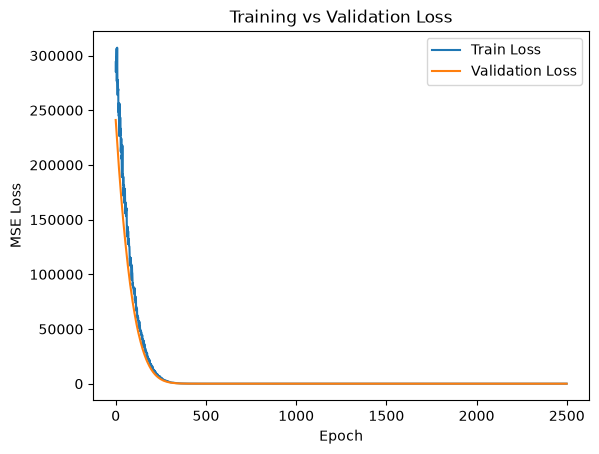

In [56]:
import matplotlib.pyplot as plt

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.show()

In [55]:
X_scaled = (X - X.mean()) / X.std()

print("Original X:")
print(X[:5].flatten())

print("\nScaled X:")
print(X_scaled[:5].flatten())

print("\nOriginal mean:", X.mean().item())
print("Scaled mean:", X_scaled.mean().item())

print("Original std:", X.std().item())
print("Scaled std:", X_scaled.std().item())

Original X:
tensor([1., 2., 3., 4., 5.])

Scaled X:
tensor([-1.7062, -1.6718, -1.6373, -1.6028, -1.5683])

Original mean: 50.5
Scaled mean: -4.76837147544984e-09
Original std: 29.011491775512695
Scaled std: 1.0


In [57]:
scaled_dataset = TensorDataset(X_scaled, y)

train_scaled, val_scaled, test_scaled = random_split(
    scaled_dataset,
    [70, 15, 15],
    generator=torch.Generator().manual_seed(42)
)

train_scaled_loader = DataLoader(
    train_scaled,
    batch_size=16,
    shuffle=True
)

print("Training samples:", len(train_scaled))
print("Validation samples:", len(val_scaled))
print("Test samples:", len(test_scaled))

Training samples: 70
Validation samples: 15
Test samples: 15


In [58]:
model_scaled = nn.Linear(1, 1)

loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model_scaled.parameters(), lr=0.01)

train_losses_scaled = []
val_losses_scaled = []

for epoch in range(2400):

    model_scaled.train()
    total_train_loss = 0

    for x_batch, y_batch in train_scaled_loader:
        optimizer.zero_grad()

        predictions = model_scaled(x_batch)
        loss = loss_fn(predictions, y_batch)

        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_scaled_loader)

    model_scaled.eval()
    total_val_loss = 0

    with torch.no_grad():
        for x_val, y_val in val_scaled:
            prediction = model_scaled(x_val.unsqueeze(0))
            val_loss = loss_fn(
                prediction,
                y_val.unsqueeze(0)
            )
            total_val_loss += val_loss.item()

    avg_val_loss = total_val_loss / len(val_scaled)

    train_losses_scaled.append(avg_train_loss)
    val_losses_scaled.append(avg_val_loss)

    if epoch % 200 == 0:
        print(
            f"Epoch {epoch}: "
            f"Train Loss = {avg_train_loss:.2f}, "
            f"Val Loss = {avg_val_loss:.2f}"
        )

Epoch 0: Train Loss = 374428.62, Val Loss = 286419.91
Epoch 200: Train Loss = 339794.84, Val Loss = 274241.73
Epoch 400: Train Loss = 321456.28, Val Loss = 262419.62
Epoch 600: Train Loss = 322405.33, Val Loss = 250956.28
Epoch 800: Train Loss = 286076.32, Val Loss = 239799.68
Epoch 1000: Train Loss = 275959.85, Val Loss = 229009.49
Epoch 1200: Train Loss = 263732.62, Val Loss = 218407.28
Epoch 1400: Train Loss = 257299.12, Val Loss = 208097.02
Epoch 1600: Train Loss = 252862.39, Val Loss = 198091.89
Epoch 1800: Train Loss = 210068.22, Val Loss = 188384.39
Epoch 2000: Train Loss = 219824.18, Val Loss = 178922.63
Epoch 2200: Train Loss = 206299.14, Val Loss = 169727.92


In [59]:
model_scaled_lr = nn.Linear(1, 1)

loss_fn = nn.MSELoss()

optimizer = torch.optim.Adam(
    model_scaled_lr.parameters(),
    lr=0.1
)

for epoch in range(2400):

    model_scaled_lr.train()
    total_train_loss = 0

    for x_batch, y_batch in train_scaled_loader:
        optimizer.zero_grad()

        predictions = model_scaled_lr(x_batch)
        loss = loss_fn(predictions, y_batch)

        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_scaled_loader)

    model_scaled_lr.eval()
    total_val_loss = 0

    with torch.no_grad():
        for x_val, y_val in val_scaled:
            prediction = model_scaled_lr(x_val.unsqueeze(0))
            val_loss = loss_fn(
                prediction,
                y_val.unsqueeze(0)
            )
            total_val_loss += val_loss.item()

    avg_val_loss = total_val_loss / len(val_scaled)

    if epoch % 200 == 0:
        print(
            f"Epoch {epoch}: "
            f"Train Loss = {avg_train_loss:.2f}, "
            f"Val Loss = {avg_val_loss:.2f}"
        )

Epoch 0: Train Loss = 326826.05, Val Loss = 284987.19
Epoch 200: Train Loss = 218011.85, Val Loss = 180803.70
Epoch 400: Train Loss = 130136.22, Val Loss = 108030.83
Epoch 600: Train Loss = 66692.17, Val Loss = 59289.45
Epoch 800: Train Loss = 31256.94, Val Loss = 28889.75
Epoch 1000: Train Loss = 12040.24, Val Loss = 11591.29
Epoch 1200: Train Loss = 3281.73, Val Loss = 3290.94
Epoch 1400: Train Loss = 493.15, Val Loss = 502.31
Epoch 1600: Train Loss = 46.41, Val Loss = 34.07
Epoch 1800: Train Loss = 28.47, Val Loss = 8.48
Epoch 2000: Train Loss = 27.14, Val Loss = 8.04
Epoch 2200: Train Loss = 24.88, Val Loss = 8.00


In [60]:
learning_rates = [0.01, 0.05, 0.1, 0.2]

results = {}

for lr in learning_rates:

    model = nn.Linear(1, 1)

    loss_fn = nn.MSELoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr
    )

    val_history = []

    for epoch in range(2400):

        model.train()

        for x_batch, y_batch in train_scaled_loader:
            optimizer.zero_grad()

            predictions = model(x_batch)
            loss = loss_fn(predictions, y_batch)

            loss.backward()
            optimizer.step()

        model.eval()

        total_val_loss = 0

        with torch.no_grad():
            for x_val, y_val in val_scaled:
                prediction = model(x_val.unsqueeze(0))

                val_loss = loss_fn(
                    prediction,
                    y_val.unsqueeze(0)
                )

                total_val_loss += val_loss.item()

        avg_val_loss = total_val_loss / len(val_scaled)
        val_history.append(avg_val_loss)

    results[lr] = val_history

    print(
        f"LR = {lr}: "
        f"Final Val Loss = {val_history[-1]:.4f}"
    )

LR = 0.01: Final Val Loss = 159497.3932
LR = 0.05: Final Val Loss = 750.8394
LR = 0.1: Final Val Loss = 7.9712
LR = 0.2: Final Val Loss = 8.1632


In [61]:
model = nn.Linear(1, 1)

loss_fn = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.1
)

train_history = []
val_history = []

for epoch in range(2400):

    # Training
    model.train()
    total_train_loss = 0

    for x_batch, y_batch in train_scaled_loader:
        optimizer.zero_grad()

        predictions = model(x_batch)
        loss = loss_fn(predictions, y_batch)

        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_scaled_loader)

    # Validation
    model.eval()
    total_val_loss = 0

    with torch.no_grad():
        for x_val, y_val in val_scaled:
            prediction = model(x_val.unsqueeze(0))

            val_loss = loss_fn(
                prediction,
                y_val.unsqueeze(0)
            )

            total_val_loss += val_loss.item()

    avg_val_loss = total_val_loss / len(val_scaled)

    train_history.append(avg_train_loss)
    val_history.append(avg_val_loss)

    if epoch % 200 == 0:
        print(
            f"Epoch {epoch}: "
            f"Train Loss = {avg_train_loss:.2f}, "
            f"Val Loss = {avg_val_loss:.2f}"
        )

Epoch 0: Train Loss = 338693.60, Val Loss = 285760.51
Epoch 200: Train Loss = 202211.39, Val Loss = 181481.29
Epoch 400: Train Loss = 133090.34, Val Loss = 108491.06
Epoch 600: Train Loss = 69156.31, Val Loss = 59684.80
Epoch 800: Train Loss = 31201.89, Val Loss = 29161.37
Epoch 1000: Train Loss = 12133.28, Val Loss = 11706.91
Epoch 1200: Train Loss = 3291.83, Val Loss = 3342.13
Epoch 1400: Train Loss = 496.92, Val Loss = 515.45
Epoch 1600: Train Loss = 50.46, Val Loss = 35.47
Epoch 1800: Train Loss = 26.43, Val Loss = 8.60
Epoch 2000: Train Loss = 26.71, Val Loss = 8.06
Epoch 2200: Train Loss = 25.81, Val Loss = 8.07


In [62]:
model.eval()

total_test_loss = 0

with torch.no_grad():
    for x_test, y_test in test_scaled:
        prediction = model(x_test.unsqueeze(0))

        test_loss = loss_fn(
            prediction,
            y_test.unsqueeze(0)
        )

        total_test_loss += test_loss.item()

avg_test_loss = total_test_loss / len(test_scaled)

print("Final Test Loss:", avg_test_loss)


Final Test Loss: 24.19417696793874


In [63]:
model.eval()

with torch.no_grad():
    sample_x = torch.tensor([
        [-1.5],
        [-0.5],
        [0.0],
        [0.5],
        [1.5]
    ])

    predictions = model(sample_x)

for x, prediction in zip(sample_x, predictions):
    print(
        f"Scaled X = {x.item():.2f} "
        f"→ Prediction = {prediction.item():.2f}"
    )

Scaled X = -1.50 → Prediction = 69.72
Scaled X = -0.50 → Prediction = 359.94
Scaled X = 0.00 → Prediction = 505.04
Scaled X = 0.50 → Prediction = 650.15
Scaled X = 1.50 → Prediction = 940.37


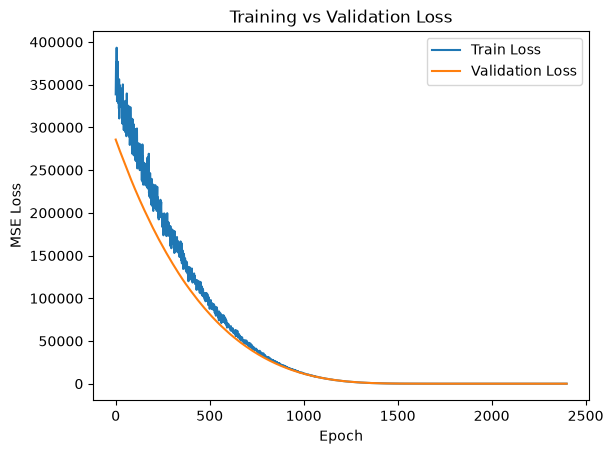

In [64]:
import matplotlib.pyplot as plt

plt.plot(train_history, label="Train Loss")
plt.plot(val_history, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.show()

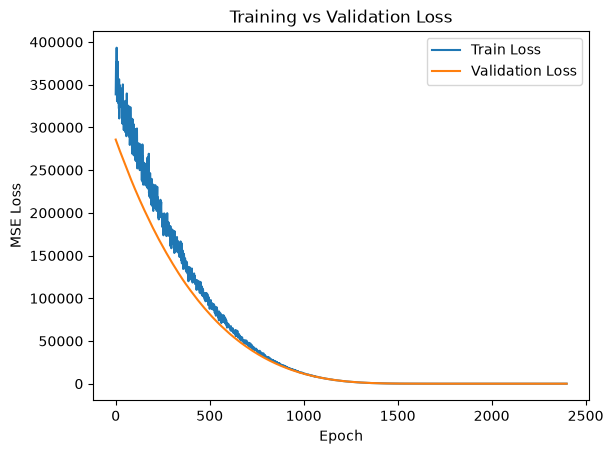

In [65]:
import matplotlib.pyplot as plt

plt.plot(train_history, label="Train Loss")
plt.plot(val_history, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.show()

In [66]:
torch.manual_seed(42)

X = torch.linspace(0, 10, 30).reshape(-1, 1)

y = 3 * X + 5 + torch.randn(30, 1) * 4

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: torch.Size([30, 1])
y shape: torch.Size([30, 1])


In [67]:
dataset = TensorDataset(X, y)

train_dataset, val_dataset = random_split(
    dataset,
    [24, 6],
    generator=torch.Generator().manual_seed(42)
)

print("Training samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))

Training samples: 24
Validation samples: 6


In [68]:
train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True
)

model = nn.Linear(1, 1)

loss_fn = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.01
)

train_history = []
val_history = []

for epoch in range(500):

    model.train()
    total_train_loss = 0

    for x_batch, y_batch in train_loader:
        optimizer.zero_grad()

        predictions = model(x_batch)
        loss = loss_fn(predictions, y_batch)

        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)

    model.eval()
    total_val_loss = 0

    with torch.no_grad():
        for x_val, y_val in val_dataset:
            prediction = model(x_val.unsqueeze(0))

            val_loss = loss_fn(
                prediction,
                y_val.unsqueeze(0)
            )

            total_val_loss += val_loss.item()

    avg_val_loss = total_val_loss / len(val_dataset)

    train_history.append(avg_train_loss)
    val_history.append(avg_val_loss)

    if epoch % 100 == 0:
        print(
            f"Epoch {epoch}: "
            f"Train Loss = {avg_train_loss:.2f}, "
            f"Val Loss = {avg_val_loss:.2f}"
        )

Epoch 0: Train Loss = 321.89, Val Loss = 324.60
Epoch 100: Train Loss = 36.45, Val Loss = 31.11
Epoch 200: Train Loss = 22.86, Val Loss = 25.76
Epoch 300: Train Loss = 22.33, Val Loss = 27.08
Epoch 400: Train Loss = 21.90, Val Loss = 27.89


In [69]:
model_complex = nn.Sequential(
    nn.Linear(1, 32),
    nn.ReLU(),
    nn.Linear(32, 32),
    nn.ReLU(),
    nn.Linear(32, 16),
    nn.ReLU(),
    nn.Linear(16, 1)
)

loss_fn = nn.MSELoss()

optimizer = torch.optim.Adam(
    model_complex.parameters(),
    lr=0.01
)

complex_train_history = []
complex_val_history = []

for epoch in range(1000):

    model_complex.train()
    total_train_loss = 0

    for x_batch, y_batch in train_loader:
        optimizer.zero_grad()

        predictions = model_complex(x_batch)
        loss = loss_fn(predictions, y_batch)

        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)

    model_complex.eval()
    total_val_loss = 0

    with torch.no_grad():
        for x_val, y_val in val_dataset:
            prediction = model_complex(x_val.unsqueeze(0))

            val_loss = loss_fn(
                prediction,
                y_val.unsqueeze(0)
            )

            total_val_loss += val_loss.item()

    avg_val_loss = total_val_loss / len(val_dataset)

    complex_train_history.append(avg_train_loss)
    complex_val_history.append(avg_val_loss)

    if epoch % 100 == 0:
        print(
            f"Epoch {epoch}: "
            f"Train Loss = {avg_train_loss:.2f}, "
            f"Val Loss = {avg_val_loss:.2f}"
        )

Epoch 0: Train Loss = 451.18, Val Loss = 441.05
Epoch 100: Train Loss = 13.75, Val Loss = 46.51
Epoch 200: Train Loss = 12.89, Val Loss = 45.81
Epoch 300: Train Loss = 12.15, Val Loss = 52.30
Epoch 400: Train Loss = 12.77, Val Loss = 48.02
Epoch 500: Train Loss = 15.47, Val Loss = 56.24
Epoch 600: Train Loss = 12.43, Val Loss = 47.85
Epoch 700: Train Loss = 12.80, Val Loss = 48.79
Epoch 800: Train Loss = 13.76, Val Loss = 51.45
Epoch 900: Train Loss = 12.51, Val Loss = 49.98


In [70]:
model_early = nn.Sequential(
    nn.Linear(1, 32),
    nn.ReLU(),
    nn.Linear(32, 32),
    nn.ReLU(),
    nn.Linear(32, 16),
    nn.ReLU(),
    nn.Linear(16, 1)
)

loss_fn = nn.MSELoss()

optimizer = torch.optim.Adam(
    model_early.parameters(),
    lr=0.01
)

best_val_loss = float("inf")
best_state = None

patience = 50
patience_counter = 0

for epoch in range(1000):

    # Training
    model_early.train()

    for x_batch, y_batch in train_loader:
        optimizer.zero_grad()

        predictions = model_early(x_batch)
        loss = loss_fn(predictions, y_batch)

        loss.backward()
        optimizer.step()

    # Validation
    model_early.eval()

    total_val_loss = 0

    with torch.no_grad():
        for x_val, y_val in val_dataset:
            prediction = model_early(x_val.unsqueeze(0))

            val_loss = loss_fn(
                prediction,
                y_val.unsqueeze(0)
            )

            total_val_loss += val_loss.item()

    avg_val_loss = total_val_loss / len(val_dataset)

    # Check improvement
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_state = model_early.state_dict()
        patience_counter = 0
    else:
        patience_counter += 1

    if epoch % 100 == 0:
        print(
            f"Epoch {epoch}: "
            f"Val Loss = {avg_val_loss:.2f}"
        )

    # Early stopping
    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch}")
        break

Epoch 0: Val Loss = 421.77
Early stopping at epoch 57


In [71]:
import copy

model_early = nn.Sequential(
    nn.Linear(1, 32),
    nn.ReLU(),
    nn.Linear(32, 32),
    nn.ReLU(),
    nn.Linear(32, 16),
    nn.ReLU(),
    nn.Linear(16, 1)
)

loss_fn = nn.MSELoss()

optimizer = torch.optim.Adam(
    model_early.parameters(),
    lr=0.01
)

best_val_loss = float("inf")
best_epoch = 0
best_state = None

patience = 50
patience_counter = 0

for epoch in range(1000):

    model_early.train()

    for x_batch, y_batch in train_loader:
        optimizer.zero_grad()

        predictions = model_early(x_batch)
        loss = loss_fn(predictions, y_batch)

        loss.backward()
        optimizer.step()

    model_early.eval()

    total_val_loss = 0

    with torch.no_grad():
        for x_val, y_val in val_dataset:
            prediction = model_early(x_val.unsqueeze(0))

            val_loss = loss_fn(
                prediction,
                y_val.unsqueeze(0)
            )

            total_val_loss += val_loss.item()

    avg_val_loss = total_val_loss / len(val_dataset)

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_epoch = epoch
        best_state = copy.deepcopy(model_early.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1

    if epoch % 50 == 0:
        print(
            f"Epoch {epoch}: "
            f"Val Loss = {avg_val_loss:.2f}, "
            f"Best = {best_val_loss:.2f}"
        )

    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch}")
        break

print("Best epoch:", best_epoch)
print("Best validation loss:", best_val_loss)

Epoch 0: Val Loss = 463.81, Best = 463.81
Epoch 50: Val Loss = 45.30, Best = 24.54
Early stopping at epoch 55
Best epoch: 5
Best validation loss: 24.537348672747612


In [72]:
model_early.load_state_dict(best_state)

print("Best model restored!")
print("Best epoch:", best_epoch)
print("Best validation loss:", best_val_loss)

Best model restored!
Best epoch: 5
Best validation loss: 24.537348672747612


In [73]:
model_early.eval()

total_test_loss = 0

with torch.no_grad():
    for x_test, y_test in test_dataset if 'test_dataset' in globals() else []:
        prediction = model_early(x_test.unsqueeze(0))

        test_loss = loss_fn(
            prediction,
            y_test.unsqueeze(0)
        )

        total_test_loss += test_loss.item()

if 'test_dataset' in globals():
    avg_test_loss = total_test_loss / len(test_dataset)
    print("Final Test Loss:", avg_test_loss)
else:
    print("We need to create a test split first.")

Final Test Loss: 151001.70849609375


In [74]:
model_reg = nn.Sequential(
    nn.Linear(1, 32),
    nn.ReLU(),
    nn.Linear(32, 32),
    nn.ReLU(),
    nn.Linear(32, 16),
    nn.ReLU(),
    nn.Linear(16, 1)
)

loss_fn = nn.MSELoss()

optimizer = torch.optim.Adam(
    model_reg.parameters(),
    lr=0.01,
    weight_decay=0.01
)

for epoch in range(500):

    model_reg.train()

    for x_batch, y_batch in train_loader:
        optimizer.zero_grad()

        predictions = model_reg(x_batch)
        loss = loss_fn(predictions, y_batch)

        loss.backward()
        optimizer.step()

    if epoch % 100 == 0:
        model_reg.eval()

        total_val_loss = 0

        with torch.no_grad():
            for x_val, y_val in val_dataset:
                prediction = model_reg(x_val.unsqueeze(0))

                val_loss = loss_fn(
                    prediction,
                    y_val.unsqueeze(0)
                )

                total_val_loss += val_loss.item()

        avg_val_loss = total_val_loss / len(val_dataset)

        print(
            f"Epoch {epoch}: "
            f"Train Loss = {loss.item():.2f}, "
            f"Val Loss = {avg_val_loss:.2f}"
        )

Epoch 0: Train Loss = 325.89, Val Loss = 399.93
Epoch 100: Train Loss = 25.50, Val Loss = 43.76
Epoch 200: Train Loss = 4.33, Val Loss = 45.34
Epoch 300: Train Loss = 15.52, Val Loss = 46.89
Epoch 400: Train Loss = 12.56, Val Loss = 53.01


In [75]:
model_dropout = nn.Sequential(
    nn.Linear(1, 32),
    nn.ReLU(),
    nn.Dropout(0.3),

    nn.Linear(32, 32),
    nn.ReLU(),
    nn.Dropout(0.3),

    nn.Linear(32, 16),
    nn.ReLU(),
    nn.Dropout(0.3),

    nn.Linear(16, 1)
)

loss_fn = nn.MSELoss()

optimizer = torch.optim.Adam(
    model_dropout.parameters(),
    lr=0.01
)

dropout_train_history = []
dropout_val_history = []

for epoch in range(500):

    model_dropout.train()
    total_train_loss = 0

    for x_batch, y_batch in train_loader:
        optimizer.zero_grad()

        predictions = model_dropout(x_batch)
        loss = loss_fn(predictions, y_batch)

        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)

    model_dropout.eval()
    total_val_loss = 0

    with torch.no_grad():
        for x_val, y_val in val_dataset:
            prediction = model_dropout(x_val.unsqueeze(0))

            val_loss = loss_fn(
                prediction,
                y_val.unsqueeze(0)
            )

            total_val_loss += val_loss.item()

    avg_val_loss = total_val_loss / len(val_dataset)

    dropout_train_history.append(avg_train_loss)
    dropout_val_history.append(avg_val_loss)

    if epoch % 100 == 0:
        print(
            f"Epoch {epoch}: "
            f"Train Loss = {avg_train_loss:.2f}, "
            f"Val Loss = {avg_val_loss:.2f}"
        )

Epoch 0: Train Loss = 435.29, Val Loss = 410.03
Epoch 100: Train Loss = 56.09, Val Loss = 37.21
Epoch 200: Train Loss = 36.14, Val Loss = 45.07
Epoch 300: Train Loss = 26.06, Val Loss = 50.44
Epoch 400: Train Loss = 16.94, Val Loss = 50.64
